# 11. Unsupervised Learning for Segmentation and Structure Discovery

Not every important decision-science problem begins with a clean target label. In many practical settings, the first analytical task is to discover structure: which accounts behave similarly, which operational regimes recur, which behavioral profiles deserve different playbooks, and which latent groups may later support supervised modeling. That is the home territory of unsupervised learning.

This notebook introduces unsupervised learning as a tool for **segmentation, exploratory structure discovery, and decision design when labels are unavailable, delayed, or incomplete**. We will build a realistic account-operations dataset, use a simple segmentation workflow to uncover structure, and then judge the result not by visual aesthetics alone but by separation, stability, and downstream usefulness. This follows the broad view of clustering as grouping unlabeled data to extract meaningful structure (Oyelade et al., 2019; Oyewole & Thopil, 2022), while also keeping in mind the long-running warning that clustering is fundamentally a user’s dilemma rather than a one-button truth machine (Jain & Law, 2005).

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain when unsupervised learning is the right first tool for a decision problem.
2. Distinguish between exploratory segmentation and supervised prediction.
3. Formalize segmentation in terms of similarity, representation, and partition objectives.
4. Use a basic unsupervised workflow to discover candidate segments in operational data.
5. Evaluate segments using internal structure, stability, and downstream actionability.
6. Recognize why visually appealing clusters still need evidence of practical meaning.


## 1. When Unsupervised Learning Is the Right Tool

Unsupervised learning becomes attractive when the analyst does **not** yet have a trustworthy label, or when the label exists but is too narrow to answer the real design question. In decision science, that happens often. A platform team may have rich behavioral logs but no clean churn label yet. A support organization may want to design differentiated service playbooks before it has a mature supervised risk model. A product team may want to understand whether its user base contains operationally distinct regimes before deciding what outcomes to predict.

The clustering literature has long treated this as a structure-discovery problem rather than a prediction problem. Oyelade, Isewon, and Oladipupo (2019) describe clustering as grouping unlabeled observations so that objects within a cluster are more similar than objects across clusters, and they note that clustering is used for segmentation, summarization, target marketing, and anomaly-oriented exploratory work. Oyewole and Thopil (2022) emphasize that clustering is widely used to extract meaning from unlabeled data but that no single clustering algorithm solves all clustering problems. That is the right spirit for this notebook: we are not searching for “the true clustering algorithm,” but for a disciplined way to use structure discovery in service of decisions.

### Mathematical Spine: Similarity, Representation, and Partitioning

Suppose we observe \(n\) units and \(p\) features, collected in a data matrix

$$
X \in \mathbb{R}^{n \times p}, \qquad x_i \in \mathbb{R}^p \text{ for } i=1,\dots,n.
$$

An unsupervised segmentation procedure typically has three ingredients:

1. a **representation** of each point,
2. a **similarity or distance notion**,
3. a **partition rule**.

A representation map may reduce or transform the original features,

$$
z_i = g(x_i), \qquad z_i \in \mathbb{R}^d,
$$

where \(d\) may equal \(p\) or be smaller than \(p\). A distance function \(D(z_i, z_j)\) defines how similar two units are. A clustering rule then assigns each point to a group label

$$
c_i \in \{1, \dots, K\}.
$$

In centroid-based clustering such as k-means, the objective is to choose cluster assignments and centroids \(\mu_1, \dots, \mu_K\) that minimize within-cluster dispersion:

$$
\min_{c_1,\dots,c_n,\,\mu_1,\dots,\mu_K}
\sum_{i=1}^n \lVert z_i - \mu_{c_i} \rVert_2^2.
$$

This is not a prediction loss over labeled outcomes. It is a compression-and-structure objective: can we summarize the cloud of points by a smaller number of coherent groups?

For visual structure discovery we often use low-dimensional projections such as principal components. If the centered feature matrix is \(\tilde X\), then the first principal component direction solves

$$
v_1 = \arg\max_{\lVert v \rVert_2 = 1} \operatorname{Var}(\tilde X v).
$$

The projected coordinates \(z_i = V^\top x_i\) are often useful for plotting, even though the clustering itself may be fit in the full standardized feature space.

One common internal validity measure is the **silhouette width**. For observation \(i\), let \(a(i)\) be its average distance to points in its own cluster and \(b(i)\) be its average distance to the nearest alternative cluster. Then

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}.
$$

Values near 1 indicate good separation, values near 0 indicate ambiguity, and negative values suggest the point may be assigned to the wrong cluster. Bolshakova and Azuaje (2003) discuss silhouette-based validation alongside other cluster validity criteria.

Good segmentation combines geometry with stability and actionability. Koepke and Clarke (2013) emphasize cluster **stability**: a useful clustering should be resistant to perturbations one would expect from the real data-generating process. In applied work, that means we care about three things at once:

- Are the clusters geometrically separated?
- Are they stable under mild perturbations?
- Do they support distinct decisions, strategies, or downstream models?


In [1]:
# Section focus: Mathematical Spine: Similarity, Representation, and Partitioning.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    adjusted_rand_score,
    average_precision_score,
    log_loss,
    normalized_mutual_info_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

sns.set_theme(style='whitegrid', palette='crest')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

rng = np.random.default_rng(2026)


## 2. Synthetic Marketplace-Operations Dataset

We will analyze a synthetic portfolio of marketplace accounts. Imagine a platform team trying to design differentiated service playbooks for sellers before a mature supervised decision stack is in place. The team observes behavior, operations, and product-usage features, but it does not begin with a label telling it what “type” of account each seller is.

The observed features include:

- `monthly_gmv_log`: account size on a log scale,
- `order_volatility`: instability in monthly order flow,
- `self_service_share`: fraction of issues resolved via self-service,
- `support_touches_30d`: recent support intensity,
- `incident_rate_90d`: rate of operational incidents,
- `feature_adoption_score`: depth of platform feature usage,
- `response_delay_hours`: average lag before platform action,
- `payment_friction_rate`: administrative/payment issues,
- `cross_border_share`: international operating footprint,
- `ad_spend_share`: dependence on promotional spend,
- `dispute_rate`: disputes and return-related conflict,
- `tenure_months`: time on the platform.

For teaching purposes only, the simulator also contains a hidden benchmark segment label and some downstream outcomes. Those are **not** used to fit the unsupervised segmentation. They exist only so we can later ask whether the discovered segments are decision-useful.


In [2]:
# Section focus: 2. Synthetic Marketplace-Operations Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


def clip_normal(mean, sd, low, high, n, rng):
    """Carry out the clip normal step used in the 11. Unsupervised Learning for Segmentation and Structure Discovery workflow.
    
    Parameters
    ----------
    mean : object
        The mean setting that controls the clip normal calculation in this notebook.
    sd : object
        The sd setting that controls the clip normal calculation in this notebook.
    low : object
        Lower value used in a range, interval, or simulation setting.
    high : object
        Upper value used in a range, interval, or simulation setting.
    n : object
        Number of observations or simulation units used by the calculation.
    rng : object
        Random number generator used to make the simulation reproducible.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    return np.clip(rng.normal(mean, sd, size=n), low, high)


def simulate_unsupervised_accounts(n=4200, random_state=2026):
    """Create a simulated unsupervised accounts data set for the 11. Unsupervised Learning for Segmentation and Structure Discovery case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)

    segment_names = [
        'Global enterprise',
        'Growth assisted',
        'Automation-first SMB',
        'Seasonal volatile',
        'Distressed friction',
    ]
    weights = np.array([0.16, 0.23, 0.28, 0.18, 0.15])
    segment_id = rng.choice(len(segment_names), size=n, p=weights)

    rows = []
    for sid in segment_id:
        size_latent = rng.normal(0, 1)
        stress_latent = rng.normal(0, 1)

        if sid == 0:  # Global enterprise
            monthly_gmv_log = clip_normal(12.2 + 0.18 * size_latent, 0.25, 11.2, 13.2, 1, rng)[0]
            order_volatility = clip_normal(0.21 + 0.04 * stress_latent, 0.05, 0.08, 0.40, 1, rng)[0]
            self_service_share = clip_normal(0.54 - 0.05 * stress_latent, 0.08, 0.20, 0.85, 1, rng)[0]
            support_touches_30d = max(1, int(rng.poisson(7.0 + 1.2 * max(stress_latent, -0.8))))
            incident_rate_90d = clip_normal(0.11 + 0.03 * stress_latent, 0.03, 0.02, 0.28, 1, rng)[0]
            feature_adoption_score = clip_normal(0.86 + 0.03 * size_latent, 0.05, 0.60, 0.98, 1, rng)[0]
            response_delay_hours = clip_normal(6.5 + 1.0 * stress_latent, 1.8, 2.0, 14.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.05 + 0.02 * stress_latent, 0.02, 0.00, 0.14, 1, rng)[0]
            cross_border_share = clip_normal(0.46 + 0.08 * size_latent, 0.10, 0.15, 0.85, 1, rng)[0]
            ad_spend_share = clip_normal(0.19 + 0.04 * stress_latent, 0.05, 0.05, 0.35, 1, rng)[0]
            dispute_rate = clip_normal(0.06 + 0.02 * stress_latent, 0.02, 0.00, 0.15, 1, rng)[0]
            tenure_months = clip_normal(42 + 7 * size_latent, 7.5, 18, 72, 1, rng)[0]

        elif sid == 1:  # Growth assisted
            monthly_gmv_log = clip_normal(11.2 + 0.22 * size_latent, 0.30, 10.2, 12.3, 1, rng)[0]
            order_volatility = clip_normal(0.28 + 0.05 * stress_latent, 0.06, 0.10, 0.48, 1, rng)[0]
            self_service_share = clip_normal(0.42 - 0.03 * stress_latent, 0.07, 0.18, 0.72, 1, rng)[0]
            support_touches_30d = max(1, int(rng.poisson(8.8 + 1.5 * max(stress_latent, -0.8))))
            incident_rate_90d = clip_normal(0.16 + 0.04 * stress_latent, 0.04, 0.04, 0.32, 1, rng)[0]
            feature_adoption_score = clip_normal(0.68 + 0.05 * size_latent, 0.07, 0.42, 0.90, 1, rng)[0]
            response_delay_hours = clip_normal(10.5 + 1.3 * stress_latent, 2.2, 4.0, 18.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.11 + 0.03 * stress_latent, 0.03, 0.02, 0.22, 1, rng)[0]
            cross_border_share = clip_normal(0.20 + 0.05 * size_latent, 0.07, 0.02, 0.45, 1, rng)[0]
            ad_spend_share = clip_normal(0.31 + 0.05 * stress_latent, 0.07, 0.08, 0.55, 1, rng)[0]
            dispute_rate = clip_normal(0.11 + 0.03 * stress_latent, 0.03, 0.02, 0.22, 1, rng)[0]
            tenure_months = clip_normal(26 + 5 * size_latent, 6.5, 8, 52, 1, rng)[0]

        elif sid == 2:  # Automation-first SMB
            monthly_gmv_log = clip_normal(9.9 + 0.20 * size_latent, 0.28, 9.1, 10.8, 1, rng)[0]
            order_volatility = clip_normal(0.18 + 0.04 * stress_latent, 0.05, 0.06, 0.36, 1, rng)[0]
            self_service_share = clip_normal(0.82 - 0.04 * stress_latent, 0.06, 0.55, 0.98, 1, rng)[0]
            support_touches_30d = max(0, int(rng.poisson(2.6 + 0.6 * max(stress_latent, -0.8))))
            incident_rate_90d = clip_normal(0.07 + 0.02 * stress_latent, 0.02, 0.01, 0.18, 1, rng)[0]
            feature_adoption_score = clip_normal(0.58 + 0.04 * size_latent, 0.08, 0.28, 0.86, 1, rng)[0]
            response_delay_hours = clip_normal(7.8 + 0.8 * stress_latent, 1.7, 2.5, 14.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.07 + 0.02 * stress_latent, 0.02, 0.00, 0.16, 1, rng)[0]
            cross_border_share = clip_normal(0.10 + 0.03 * size_latent, 0.04, 0.00, 0.25, 1, rng)[0]
            ad_spend_share = clip_normal(0.12 + 0.03 * stress_latent, 0.04, 0.00, 0.26, 1, rng)[0]
            dispute_rate = clip_normal(0.05 + 0.02 * stress_latent, 0.02, 0.00, 0.14, 1, rng)[0]
            tenure_months = clip_normal(18 + 4 * size_latent, 5.0, 4, 36, 1, rng)[0]

        elif sid == 3:  # Seasonal volatile
            monthly_gmv_log = clip_normal(10.7 + 0.24 * size_latent, 0.35, 9.7, 11.8, 1, rng)[0]
            order_volatility = clip_normal(0.47 + 0.08 * stress_latent, 0.07, 0.22, 0.70, 1, rng)[0]
            self_service_share = clip_normal(0.38 - 0.02 * stress_latent, 0.07, 0.14, 0.62, 1, rng)[0]
            support_touches_30d = max(1, int(rng.poisson(6.2 + 1.3 * max(stress_latent, -0.8))))
            incident_rate_90d = clip_normal(0.18 + 0.05 * stress_latent, 0.04, 0.05, 0.36, 1, rng)[0]
            feature_adoption_score = clip_normal(0.52 + 0.04 * size_latent, 0.07, 0.28, 0.76, 1, rng)[0]
            response_delay_hours = clip_normal(12.5 + 1.5 * stress_latent, 2.4, 5.0, 22.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.10 + 0.03 * stress_latent, 0.03, 0.02, 0.22, 1, rng)[0]
            cross_border_share = clip_normal(0.16 + 0.04 * size_latent, 0.05, 0.02, 0.35, 1, rng)[0]
            ad_spend_share = clip_normal(0.51 + 0.07 * stress_latent, 0.08, 0.20, 0.80, 1, rng)[0]
            dispute_rate = clip_normal(0.10 + 0.03 * stress_latent, 0.03, 0.01, 0.22, 1, rng)[0]
            tenure_months = clip_normal(22 + 4 * size_latent, 5.5, 6, 40, 1, rng)[0]

        else:  # Distressed friction
            monthly_gmv_log = clip_normal(10.1 + 0.18 * size_latent, 0.30, 9.2, 11.1, 1, rng)[0]
            order_volatility = clip_normal(0.34 + 0.07 * stress_latent, 0.06, 0.14, 0.58, 1, rng)[0]
            self_service_share = clip_normal(0.24 - 0.03 * stress_latent, 0.06, 0.05, 0.48, 1, rng)[0]
            support_touches_30d = max(2, int(rng.poisson(10.2 + 1.9 * max(stress_latent, -0.8))))
            incident_rate_90d = clip_normal(0.26 + 0.06 * stress_latent, 0.05, 0.08, 0.45, 1, rng)[0]
            feature_adoption_score = clip_normal(0.31 + 0.03 * size_latent, 0.07, 0.10, 0.58, 1, rng)[0]
            response_delay_hours = clip_normal(18.8 + 2.0 * stress_latent, 3.2, 8.0, 32.0, 1, rng)[0]
            payment_friction_rate = clip_normal(0.31 + 0.06 * stress_latent, 0.05, 0.12, 0.55, 1, rng)[0]
            cross_border_share = clip_normal(0.12 + 0.03 * size_latent, 0.05, 0.00, 0.28, 1, rng)[0]
            ad_spend_share = clip_normal(0.22 + 0.05 * stress_latent, 0.06, 0.04, 0.42, 1, rng)[0]
            dispute_rate = clip_normal(0.24 + 0.05 * stress_latent, 0.04, 0.08, 0.42, 1, rng)[0]
            tenure_months = clip_normal(13 + 3 * size_latent, 4.5, 2, 28, 1, rng)[0]

        support_hours_next_month = max(
            1.2,
            0.55 * support_touches_30d
            + 18.0 * incident_rate_90d
            + 3.0 * payment_friction_rate
            + 0.18 * response_delay_hours
            + 4.5 * order_volatility
            + rng.normal(0, 1.5),
        )

        breach_logit = (
            -4.1
            + 4.0 * incident_rate_90d
            + 3.4 * payment_friction_rate
            + 0.08 * response_delay_hours
            + 0.10 * support_touches_30d
            + 1.8 * order_volatility
            - 1.6 * feature_adoption_score
            - 1.0 * self_service_share
            + 0.9 * (dispute_rate > 0.18)
            + 0.8 * ((order_volatility > 0.42) and (ad_spend_share > 0.45))
            + 1.0 * ((payment_friction_rate > 0.24) and (response_delay_hours > 16))
        )
        breach_next_month = rng.binomial(1, 1 / (1 + np.exp(-breach_logit)))

        expansion_logit = (
            -2.6
            + 0.9 * (monthly_gmv_log - 10.4)
            + 2.1 * feature_adoption_score
            + 0.7 * cross_border_share
            - 2.0 * payment_friction_rate
            - 1.3 * incident_rate_90d
            - 0.6 * order_volatility
            + 0.4 * (sid == 1)
            + 0.5 * (sid == 0)
        )
        expansion_next_quarter = rng.binomial(1, 1 / (1 + np.exp(-expansion_logit)))

        rows.append({
            'true_segment': segment_names[sid],
            'monthly_gmv_log': monthly_gmv_log,
            'order_volatility': order_volatility,
            'self_service_share': self_service_share,
            'support_touches_30d': support_touches_30d,
            'incident_rate_90d': incident_rate_90d,
            'feature_adoption_score': feature_adoption_score,
            'response_delay_hours': response_delay_hours,
            'payment_friction_rate': payment_friction_rate,
            'cross_border_share': cross_border_share,
            'ad_spend_share': ad_spend_share,
            'dispute_rate': dispute_rate,
            'tenure_months': tenure_months,
            'support_hours_next_month': support_hours_next_month,
            'breach_next_month': breach_next_month,
            'expansion_next_quarter': expansion_next_quarter,
        })

    return pd.DataFrame(rows)


df_segments = simulate_unsupervised_accounts()

feature_cols = [
    'monthly_gmv_log',
    'order_volatility',
    'self_service_share',
    'support_touches_30d',
    'incident_rate_90d',
    'feature_adoption_score',
    'response_delay_hours',
    'payment_friction_rate',
    'cross_border_share',
    'ad_spend_share',
    'dispute_rate',
    'tenure_months',
]

portfolio_overview = pd.DataFrame([
    {
        'accounts': len(df_segments),
        'breach_rate': df_segments['breach_next_month'].mean(),
        'expansion_rate': df_segments['expansion_next_quarter'].mean(),
        'avg_support_hours': df_segments['support_hours_next_month'].mean(),
        'avg_self_service_share': df_segments['self_service_share'].mean(),
        'avg_order_volatility': df_segments['order_volatility'].mean(),
    }
])
portfolio_overview


,accounts,breach_rate,expansion_rate,avg_support_hours,avg_self_service_share,avg_order_volatility
0,4200,0.199,0.281,9.876,0.518,0.286


The practical question in Synthetic Marketplace-Operations Dataset is simple. What would this result make the analyst do differently?


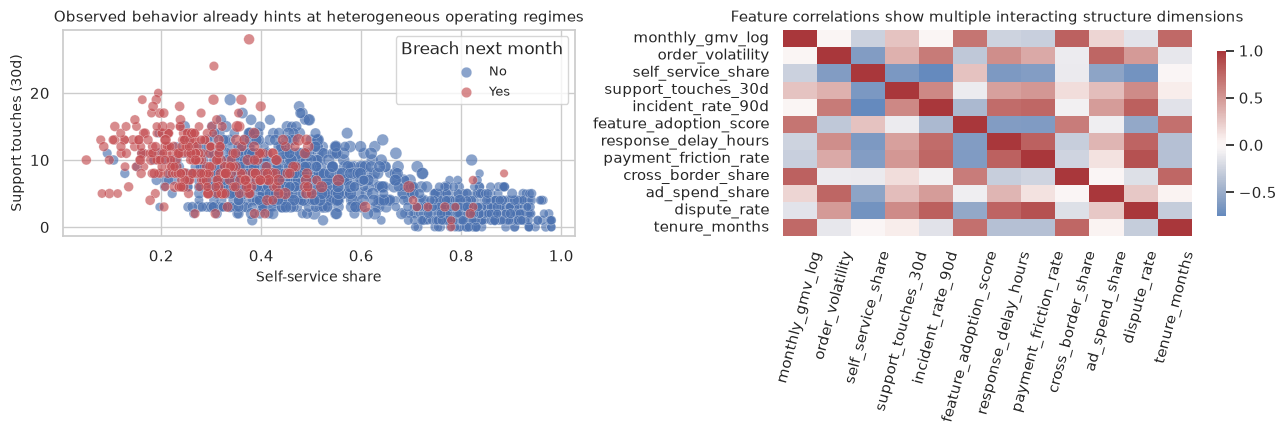

In [3]:
# Section focus: 2. Synthetic Marketplace-Operations Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.5))

sample_view = df_segments.sample(n=1600, random_state=12)
palette = {0: '#4c72b0', 1: '#c44e52'}
labels = {0: 'No', 1: 'Yes'}

for breach_value in [0, 1]:
    subset = sample_view.loc[sample_view['breach_next_month'] == breach_value]
    axes[0].scatter(
        subset['self_service_share'],
        subset['support_touches_30d'],
        color=palette[breach_value],
        alpha=0.65,
        s=35 + 12 * (subset['monthly_gmv_log'] - sample_view['monthly_gmv_log'].min()),
        edgecolor='white',
        linewidth=0.25,
        label=labels[breach_value],
    )

axes[0].set_title('Observed behavior already hints at heterogeneous operating regimes')
axes[0].set_xlabel('Self-service share')
axes[0].set_ylabel('Support touches (30d)')
axes[0].legend(title='Breach next month', loc='upper right')

corr = df_segments[feature_cols].corr()
sns.heatmap(corr, cmap='vlag', center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature correlations show multiple interacting structure dimensions')
axes[1].tick_params(axis='x', rotation=75)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()

Use the Synthetic Marketplace-Operations Dataset output to decide what the analysis should do next. The decision value lies in the part of the result that changes the next step.


### Discussion of the Data-Generating Process

The analyst does not observe the hidden segment labels. What they see is a mixture of behavioral and operational signals that reflect account size, service intensity, product adoption, administrative friction, and volatility. That is exactly the kind of setting where unsupervised learning can be valuable: there is structure, but it is not handed to us as a target column.

The raw plots already suggest that a single “average account” description would be misleading. Some accounts are highly self-service and light-touch. Others are support-heavy with elevated friction. Some combine volatility with marketing dependence. Others are globally scaled and feature-rich. The point of segmentation is to compress that heterogeneity into a smaller number of analytically and operationally meaningful profiles.


## 3. Exploratory Structure Before Naming Segments

We begin with a simple but defensible workflow:

1. standardize the features so scale does not dominate the geometry,
2. inspect a low-dimensional PCA projection for broad structure,
3. examine candidate values of \(K\) using internal criteria,
4. choose a working segmentation that balances separation, interpretability, and stability.

This notebook uses k-means as the first working segmentation tool because the goal here is not to compare clustering algorithms yet. The algorithm-comparison notebook comes next. For now, k-means is just a practical scaffold for learning how unsupervised segmentation behaves.


In [4]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_segments[feature_cols])

pca = PCA(n_components=2, random_state=12)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

candidate_rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=25, random_state=12)
    labels = km.fit_predict(X_scaled)
    counts = pd.Series(labels).value_counts().sort_index()
    candidate_rows.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'inertia': km.inertia_,
        'smallest_cluster_share': counts.min() / counts.sum(),
        'largest_cluster_share': counts.max() / counts.sum(),
    })

candidate_table = pd.DataFrame(candidate_rows)
candidate_table


,k,silhouette,inertia,smallest_cluster_share,largest_cluster_share
0,2,0.296,"33,977.942",0.391,0.609
1,3,0.327,"24,579.676",0.295,0.360
2,4,0.390,"17,077.666",0.143,0.384
3,5,0.356,"14,591.723",0.143,0.285
4,6,0.332,"13,656.536",0.070,0.285
5,7,0.294,"12,859.830",0.069,0.283
6,8,0.288,"12,192.191",0.073,0.284


In Exploratory Structure Before Naming Segments, the point of the output is practical. The result should guide a specific choice rather than sit as a summary statistic.


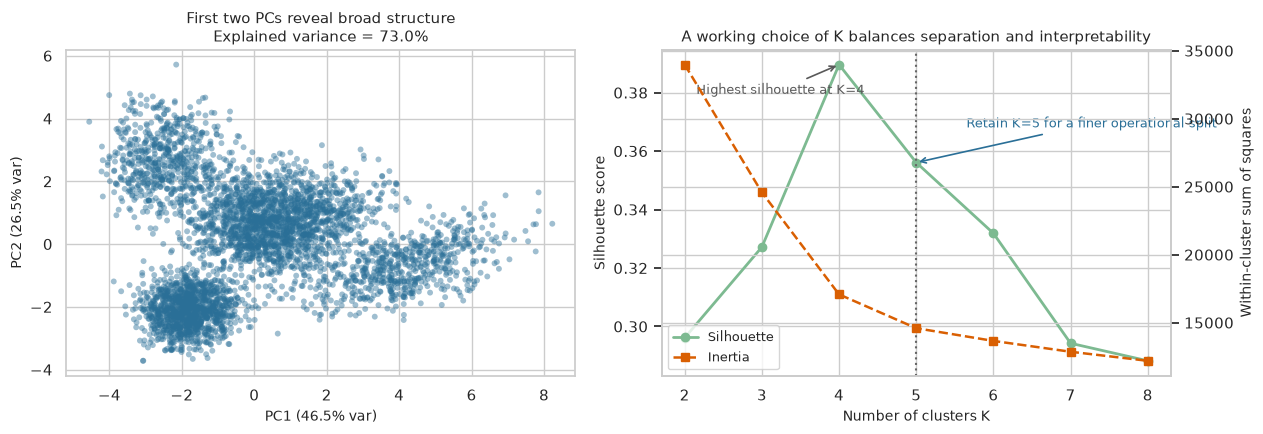

In [5]:
# Section focus: 3. Exploratory Structure Before Naming Segments.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

chosen_k = 5
peak_row = candidate_table.loc[candidate_table['silhouette'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], s=18, alpha=0.45, color='#2a6f97', edgecolor='none')
axes[0].set_title(
    f'First two PCs reveal broad structure\nExplained variance = {100*explained.sum():.1f}%'
)
axes[0].set_xlabel(f'PC1 ({100*explained[0]:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({100*explained[1]:.1f}% var)')

axes[1].plot(candidate_table['k'], candidate_table['silhouette'], marker='o', linewidth=2, label='Silhouette')
ax2 = axes[1].twinx()
ax2.plot(candidate_table['k'], candidate_table['inertia'], marker='s', linestyle='--', linewidth=1.8, color='#d95f02', label='Inertia')
axes[1].axvline(chosen_k, linestyle=':', linewidth=1.5, color='0.4')
axes[1].set_title('A working choice of K balances separation and interpretability')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette score')
ax2.set_ylabel('Within-cluster sum of squares')

axes[1].annotate(
    'Highest silhouette at K=4',
    xy=(peak_row['k'], peak_row['silhouette']),
    xytext=(2.15, peak_row['silhouette'] - 0.010),
    arrowprops=dict(arrowstyle='->', color='0.35', lw=1.2),
    fontsize=9.5,
    color='0.35',
)
chosen_silhouette = candidate_table.loc[candidate_table['k'] == chosen_k, 'silhouette'].iat[0]
axes[1].annotate(
    'Retain K=5 for a finer operational split',
    xy=(chosen_k, chosen_silhouette),
    xytext=(5.65, chosen_silhouette + 0.012),
    arrowprops=dict(arrowstyle='->', color='#2a6f97', lw=1.2),
    fontsize=9.5,
    color='#2a6f97',
)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()

Exploratory Structure Before Naming Segments gives a checkpoint for the decision workflow. Use the pattern to make the next model or operating rule more defensible.


### Discussion of the Exploratory Evidence

The PCA view does not prove that there are exactly five natural groups, but it does suggest that the data are not structureless. The candidate-\(K\) table and plot help convert that impression into a working segmentation decision.

A high silhouette score alone should not decide \(K\). Analysts also care about whether the resulting segments are large enough to matter, distinct enough to support different playbooks, and stable enough that minor perturbations do not completely reorder the segmentation. In this simulator, the silhouette peaks at \(K=4\), but \(K=5\) preserves an additional regime that is operationally distinct and still well-supported by the diagnostics. That is a realistic lesson: internal metrics help narrow the search, but analysts still have to make an interpretable modeling choice.

## 4. A First Working Segmentation and Its Operational Profiles

Now we fit the working segmentation, profile the discovered clusters, and only then attach interpretable names. That ordering matters. If we name first and inspect later, we risk forcing a story onto the partition. If we inspect the profile table first, the names become summaries rather than assumptions.


In [6]:
# Section focus: 4. A First Working Segmentation and Its Operational Profiles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


km_final = KMeans(n_clusters=chosen_k, n_init=25, random_state=12)
df_segments['cluster_id'] = km_final.fit_predict(X_scaled)

cluster_centers_original = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=feature_cols,
)
cluster_centers_original['cluster_id'] = cluster_centers_original.index


def assign_cluster_name(row):
    """Carry out the assign cluster name step used in the 11. Unsupervised Learning for Segmentation and Structure Discovery workflow.
    
    Parameters
    ----------
    row : object
        Single data-frame row representing one unit in the current decision example.
    
    Returns
    -------
    object
        Intermediate result produced by the assign cluster name calculation and reused by later cells.
    """
    if row['payment_friction_rate'] > 0.22 or row['response_delay_hours'] > 16:
        return 'Distressed friction'
    if row['self_service_share'] > 0.70 and row['support_touches_30d'] < 4.5:
        return 'Automation-first SMB'
    if row['monthly_gmv_log'] > 11.5 and row['cross_border_share'] > 0.30:
        return 'Global enterprise'
    if row['order_volatility'] > 0.38 and row['ad_spend_share'] > 0.38:
        return 'Seasonal volatile'
    return 'Growth assisted'

cluster_centers_original['cluster_name'] = cluster_centers_original.apply(assign_cluster_name, axis=1)

# Ensure unique names even if two clusters trigger the same rule.
if cluster_centers_original['cluster_name'].duplicated().any():
    cluster_centers_original = cluster_centers_original.sort_values('cluster_id').copy()
    cluster_centers_original['cluster_name'] = [f"Segment {i+1}" for i in range(len(cluster_centers_original))]

name_map = cluster_centers_original.set_index('cluster_id')['cluster_name'].to_dict()
df_segments['cluster_name'] = df_segments['cluster_id'].map(name_map)

profile_table = (
    df_segments.groupby('cluster_name', observed=False)
    .agg(
        accounts=('cluster_id', 'size'),
        monthly_gmv_log=('monthly_gmv_log', 'mean'),
        order_volatility=('order_volatility', 'mean'),
        self_service_share=('self_service_share', 'mean'),
        support_touches_30d=('support_touches_30d', 'mean'),
        incident_rate_90d=('incident_rate_90d', 'mean'),
        feature_adoption_score=('feature_adoption_score', 'mean'),
        response_delay_hours=('response_delay_hours', 'mean'),
        payment_friction_rate=('payment_friction_rate', 'mean'),
        breach_next_month=('breach_next_month', 'mean'),
        expansion_next_quarter=('expansion_next_quarter', 'mean'),
        support_hours_next_month=('support_hours_next_month', 'mean'),
    )
    .sort_values('accounts', ascending=False)
    .reset_index()
)
profile_table


,cluster_name,accounts,monthly_gmv_log,order_volatility,self_service_share,support_touches_30d,incident_rate_90d,feature_adoption_score,response_delay_hours,payment_friction_rate,breach_next_month,expansion_next_quarter,support_hours_next_month
0,Automation-first SMB,1199,9.898,0.183,0.817,2.711,0.071,0.581,7.832,0.070,0.022,0.120,5.234
1,Growth assisted,1046,11.153,0.276,0.421,8.772,0.153,0.667,10.374,0.104,0.082,0.379,10.990
2,Seasonal volatile,723,10.702,0.480,0.376,6.696,0.191,0.530,12.936,0.110,0.271,0.165,11.938
3,Global enterprise,632,12.188,0.212,0.541,7.076,0.110,0.860,6.555,0.051,0.032,0.775,8.128
4,Distressed friction,600,10.091,0.351,0.237,10.588,0.267,0.306,18.934,0.318,0.843,0.050,16.563


The A First Working Segmentation and Its Operational Profiles result matters when it changes the next move. The result should help make the next workflow decision less vague.


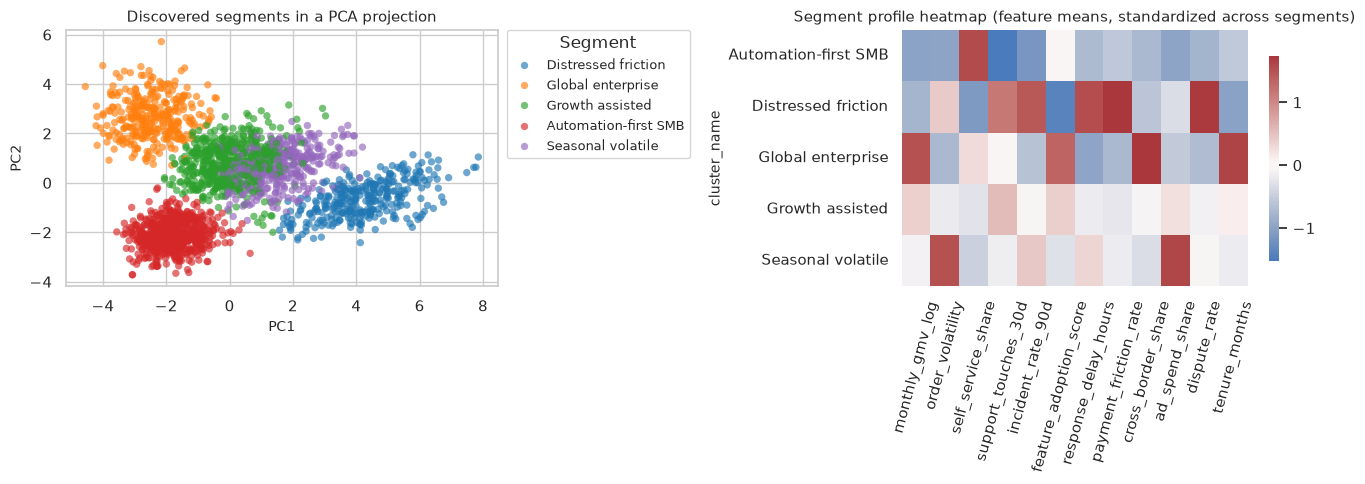

In [7]:
# Section focus: 4. A First Working Segmentation and Its Operational Profiles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


profile_z = (
    df_segments.groupby('cluster_name', observed=False)[feature_cols]
    .mean()
    .apply(lambda col: (col - col.mean()) / col.std(), axis=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))

plot_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'cluster_name': df_segments['cluster_name']})
sns.scatterplot(
    data=plot_df.sample(n=min(2200, len(plot_df)), random_state=7),
    x='PC1',
    y='PC2',
    hue='cluster_name',
    palette='tab10',
    s=28,
    alpha=0.65,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title('Discovered segments in a PCA projection')
axes[0].legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

sns.heatmap(profile_z, cmap='vlag', center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Segment profile heatmap (feature means, standardized across segments)')
axes[1].tick_params(axis='x', rotation=75)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()


Read A First Working Segmentation and Its Operational Profiles as a decision checkpoint. The analyst should be able to connect the pattern to a real choice.


### Discussion of the Segment Profiles

The clustering output becomes useful only when we can translate geometry into operational meaning. The profile table and heatmap help with that translation.

A good segmentation should compress a noisy, high-dimensional portfolio into a handful of recognizable regimes. Here, the discovered groups line up with practical patterns: a large globally scaled cohort, a self-service-heavy low-touch cohort, a growth cohort that consumes more assisted support, a seasonal cohort defined by volatility and marketing dependence, and a distressed cohort defined by friction, slow response, and high support burden.

The important methodological point is that these labels are **summaries of the discovered profiles**, not target labels the algorithm was given. That is why profiling comes before storytelling.


## 5. Usefulness Is Not the Same as Truth

A cluster solution can look tidy and still be brittle or irrelevant. This section checks three different standards:

1. **internal separation**: are the groups reasonably compact and distinct?
2. **stability**: do small perturbations produce similar assignments?
3. **teaching benchmark**: how close is the discovered segmentation to the simulator’s hidden segment structure?

The third criterion is included only because this is synthetic data. In real applications, analysts usually do not have such a benchmark. That is exactly why stability and downstream usefulness matter so much.


In [8]:
# Section focus: 5. Usefulness Is Not the Same as Truth.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


base_labels = df_segments['cluster_id'].to_numpy()
base_silhouette = silhouette_score(X_scaled, base_labels)

stability_scores = []
for seed in range(30):
    noise_rng = np.random.default_rng(500 + seed)
    X_perturbed = X_scaled + noise_rng.normal(0, 0.08, size=X_scaled.shape)
    perturbed_labels = KMeans(n_clusters=chosen_k, n_init=20, random_state=500 + seed).fit_predict(X_perturbed)
    stability_scores.append(adjusted_rand_score(base_labels, perturbed_labels))

benchmark_ari = adjusted_rand_score(df_segments['true_segment'], df_segments['cluster_name'])
benchmark_nmi = normalized_mutual_info_score(df_segments['true_segment'], df_segments['cluster_name'])

validation_summary = pd.DataFrame([
    {
        'k': chosen_k,
        'silhouette_score': base_silhouette,
        'perturbation_stability_mean_ARI': np.mean(stability_scores),
        'perturbation_stability_std_ARI': np.std(stability_scores),
        'hidden_benchmark_ARI': benchmark_ari,
        'hidden_benchmark_NMI': benchmark_nmi,
    }
])
validation_summary


,k,silhouette_score,perturbation_stability_mean_ARI,perturbation_stability_std_ARI,hidden_benchmark_ARI,hidden_benchmark_NMI
0,5,0.356,0.980,0.003,0.876,0.865


The practical question in Usefulness Is Not the Same as Truth is simple. What would this result make the analyst do differently?


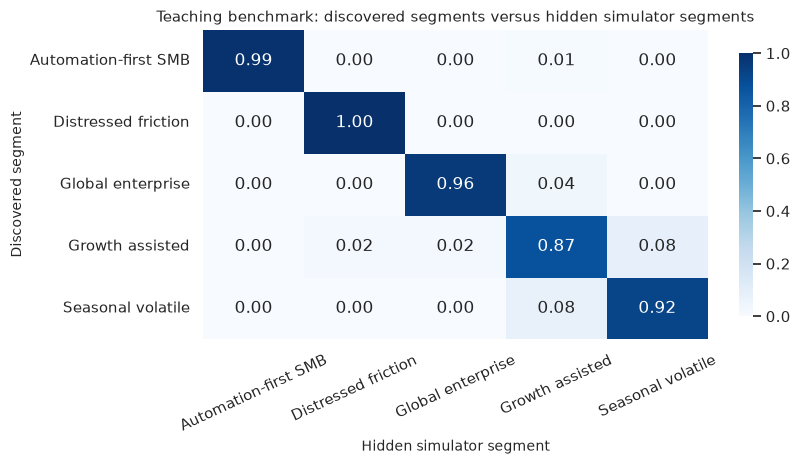

In [9]:

confusion = pd.crosstab(df_segments['cluster_name'], df_segments['true_segment'], normalize='index')

fig, ax = plt.subplots(figsize=(8.6, 4.8))
sns.heatmap(confusion, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar_kws={'shrink': 0.85})
ax.set_title('Teaching benchmark: discovered segments versus hidden simulator segments')
ax.set_xlabel('Hidden simulator segment')
ax.set_ylabel('Discovered segment')
ax.tick_params(axis='x', rotation=25)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()


The metric result should be read as an operating tradeoff. In Usefulness Is Not the Same as Truth, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. At this point, scorekeeping should give way to a concrete threshold or review decision.


### Discussion of Validity and Caution

The benchmark heatmap usually shows a reassuring but imperfect pattern: several discovered segments line up strongly with the hidden simulator groups, but the correspondence is not one-to-one. That is exactly the right lesson. Useful unsupervised structure does not have to reproduce some metaphysical truth perfectly in order to support better decisions.

The stability check matters for the same reason. Koepke and Clarke (2013) describe stable clustering as resistance to changes one would expect from a real-data generator. In practice, a segmentation that changes radically under mild perturbations is dangerous because the playbooks derived from it will not be trustworthy.

So the right question is not “Did we find the truth?” The right question is “Did we find a stable, interpretable partition that reveals actionable heterogeneity?”


## 6. From Segments to Playbooks and Downstream Models

A segmentation becomes valuable when it changes how the organization works. We will show two practical uses:

1. **segment-level playbooks** built from risk, burden, and opportunity differences,
2. **downstream supervised modeling** where segment membership acts as a compact nonlinear feature for a simple classifier.


In [10]:

action_table = profile_table.copy()
action_table['primary_playbook'] = [
    'Dedicated account governance and cross-border support planning' if name == 'Global enterprise' else
    'Proactive success-manager outreach and adoption expansion' if name == 'Growth assisted' else
    'Automation-first support, nudges, and low-cost self-service optimization' if name == 'Automation-first SMB' else
    'Seasonal staffing buffers and campaign-risk monitoring' if name == 'Seasonal volatile' else
    'Rapid-friction escalation, payment remediation, and specialist queue routing'
    for name in action_table['cluster_name']
]
action_table[['cluster_name', 'accounts', 'breach_next_month', 'expansion_next_quarter', 'support_hours_next_month', 'primary_playbook']]


,cluster_name,accounts,breach_next_month,expansion_next_quarter,support_hours_next_month,primary_playbook
0,Automation-first SMB,1199,0.022,0.120,5.234,"Automation-first support, nudges, and low-cost self-service optimization"
1,Growth assisted,1046,0.082,0.379,10.990,Proactive success-manager outreach and adoption expansion
2,Seasonal volatile,723,0.271,0.165,11.938,Seasonal staffing buffers and campaign-risk monitoring
3,Global enterprise,632,0.032,0.775,8.128,Dedicated account governance and cross-border support planning
4,Distressed friction,600,0.843,0.050,16.563,"Rapid-friction escalation, payment remediation, and specialist queue routing"


Use the From Segments to Playbooks and Downstream Models output to decide what the analysis should do next. The important comparison is the one with consequences for modeling, diagnostics, thresholds, or governance.


In [11]:
# Section focus: 6. From Segments to Playbooks and Downstream Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


train_idx, test_idx = train_test_split(
    np.arange(len(df_segments)),
    test_size=0.30,
    random_state=21,
    stratify=df_segments['breach_next_month'],
)

train_df = df_segments.iloc[train_idx].copy()
test_df = df_segments.iloc[test_idx].copy()

feature_scaler = StandardScaler()
X_train_base = feature_scaler.fit_transform(train_df[feature_cols])
X_test_base = feature_scaler.transform(test_df[feature_cols])
y_train = train_df['breach_next_month'].to_numpy()
y_test = test_df['breach_next_month'].to_numpy()

baseline_logit = LogisticRegression(max_iter=4000)
baseline_logit.fit(X_train_base, y_train)
base_probs = baseline_logit.predict_proba(X_test_base)[:, 1]

train_kmeans = KMeans(n_clusters=chosen_k, n_init=25, random_state=21)
train_clusters = train_kmeans.fit_predict(X_train_base)
test_clusters = train_kmeans.predict(X_test_base)

train_cluster_dummies = pd.get_dummies(train_clusters, prefix='cluster', drop_first=False)
test_cluster_dummies = pd.get_dummies(test_clusters, prefix='cluster', drop_first=False)
train_cluster_dummies, test_cluster_dummies = train_cluster_dummies.align(test_cluster_dummies, join='left', axis=1, fill_value=0)

X_train_plus = np.column_stack([X_train_base, train_cluster_dummies.to_numpy()])
X_test_plus = np.column_stack([X_test_base, test_cluster_dummies.to_numpy()])

cluster_logit = LogisticRegression(max_iter=4000)
cluster_logit.fit(X_train_plus, y_train)
cluster_probs = cluster_logit.predict_proba(X_test_plus)[:, 1]

downstream_table = pd.DataFrame([
    {
        'model': 'Logistic on raw features',
        'roc_auc': roc_auc_score(y_test, base_probs),
        'average_precision': average_precision_score(y_test, base_probs),
        'log_loss': log_loss(y_test, base_probs),
    },
    {
        'model': 'Logistic on raw features + unsupervised segment dummies',
        'roc_auc': roc_auc_score(y_test, cluster_probs),
        'average_precision': average_precision_score(y_test, cluster_probs),
        'log_loss': log_loss(y_test, cluster_probs),
    },
])
downstream_table


,model,roc_auc,average_precision,log_loss
0,Logistic on raw features,0.931,0.858,0.232
1,Logistic on raw features + unsupervised segment dummies,0.933,0.862,0.228


In From Segments to Playbooks and Downstream Models, the point of the output is practical. This should point to the next modeling move or review rule.


### Discussion of Downstream Use

The playbook table shows the most immediate value of unsupervised learning: even without fitting a supervised outcome model, the discovered segments support differentiated action. Some cohorts deserve automation-first treatment, some deserve proactive success coverage, some require seasonal staffing buffers, and some need specialist remediation.

The downstream modeling table makes a subtler point. Segment membership is a nonlinear summary of the feature space. When we append those segment indicators to a simple linear logistic model, we often recover a small but real improvement because the segments encode interactions and regimes that are awkward to express with a plain linear decision boundary. Clustering can sometimes help bridge exploratory analysis and predictive modeling, but the gain must be checked rather than assumed.


## 7. Practical Checklist

When using unsupervised learning in applied decision work, ask:

1. Why is segmentation needed before or alongside supervised modeling?
2. Which features define similarity, and how sensitive is the result to scaling or representation?
3. Is the chosen number of segments large enough to capture heterogeneity but small enough to support action?
4. Are the discovered segments stable under mild perturbations?
5. Do the profiles support distinct operational playbooks, beyond pretty plots?
6. Are we careful not to confuse a useful partition with a revealed ground truth?
7. If clusters are reused downstream, are they created in a training-only workflow rather than leaking test information?


## Wrap-Up

Unsupervised learning is often the first serious analytical move in messy operational settings. It helps transform unlabeled heterogeneity into candidate regimes, segment-specific strategies, and compact structure that later supervised models can reuse.

The deeper lesson is methodological. Segmentation is not a decorative dashboard step. It is a modeling choice about representation, similarity, and action. Good unsupervised work therefore needs a clear use case, careful validation, and discipline about what the discovered groups do and do not mean.

## References

- Bolshakova, N., & Azuaje, F. (2003). *Improving expression data mining through cluster validation*. [https://doi.org/10.1109/ITAB.2003.1222407](https://doi.org/10.1109/ITAB.2003.1222407)
- Jain, A. K., & Law, M. H. C. (2005). *Data Clustering: A User’s Dilemma*. [https://doi.org/10.1007/11590316_1](https://doi.org/10.1007/11590316_1)
- Koepke, H., & Clarke, B. (2013). *A Bayesian criterion for cluster stability*. *Statistical Analysis and Data Mining*, 6(4), 346-374. [https://doi.org/10.1002/sam.11176](https://doi.org/10.1002/sam.11176)
- Oyelade, J., Isewon, I., Oladipupo, O., Emebo, O., Omogbadegun, Z., Aromolaran, O., Uwoghiren, E., Olaniyan, D., & Olawole, O. (2019). *Data Clustering: Algorithms and Its Applications*. [https://doi.org/10.1109/ICCSA.2019.000-1](https://doi.org/10.1109/ICCSA.2019.000-1)
- Oyewole, G. J., & Thopil, G. A. (2023). *Data clustering: application and trends*. *Artificial Intelligence Review*, 56(7), 6439-6475. [https://doi.org/10.1007/s10462-022-10325-y](https://doi.org/10.1007/s10462-022-10325-y)
